<a href="https://colab.research.google.com/github/FaridRash/brain-ct-hemorrhage-segmentation/blob/main/Notebooks/03_Brain_Extraction_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/brain_ct_project/processed_data_full.zip'
extract_dir = '/content/processed_data_full_extracted'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"File unzipped to: {extract_dir}")
!ls {extract_dir}

File unzipped to: /content/processed_data_full_extracted
test  train  val


#Load Data


Processing train | Total samples: 2281


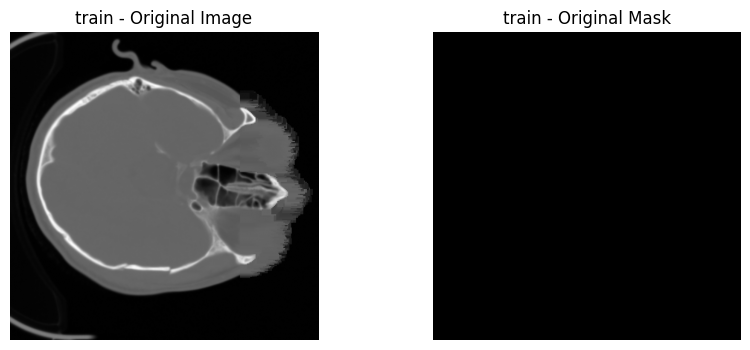

train done.

Processing val | Total samples: 241


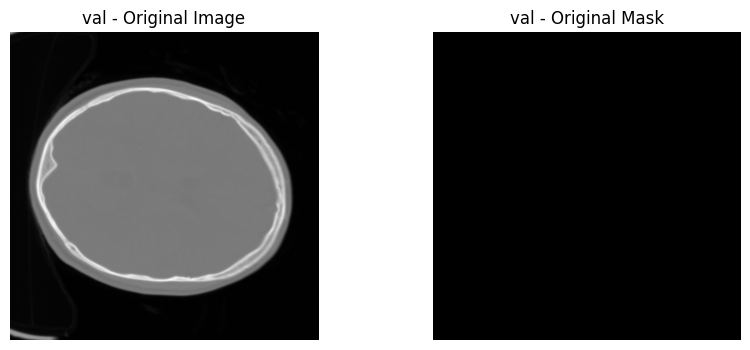

val done.

Processing test | Total samples: 292


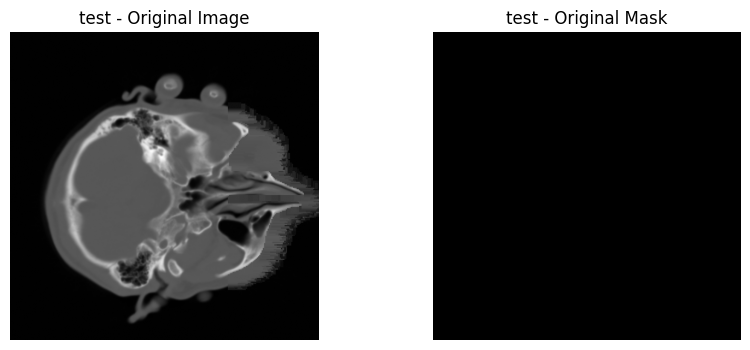

test done.


In [51]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt

splits = ['train', 'val', 'test']

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))  # FIX: ensure consistent ordering

    print(f"\nProcessing {split} | Total samples: {len(files)}")

    # pick ONE random sample for visualization
    sample_file = random.choice(files)

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        # FIX: ensure mask exists (important for pipeline safety)
        if not os.path.exists(mask_path):
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        # FIX: sanity check (very important early)
        if img.shape != mask.shape:
            print(f"Shape mismatch in {f}: {img.shape} vs {mask.shape}")
            continue

        # ONLY visualize one sample
        if f == sample_file:
            plt.figure(figsize=(10,4))

            plt.subplot(1,2,1)
            plt.title(f"{split} - Original Image")
            plt.imshow(img, cmap='gray')
            plt.axis('off')

            plt.subplot(1,2,2)
            plt.title(f"{split} - Original Mask")
            plt.imshow(mask, cmap='gray')
            plt.axis('off')

            plt.show()

    print(f"{split} done.")

#Air removal


Processing train


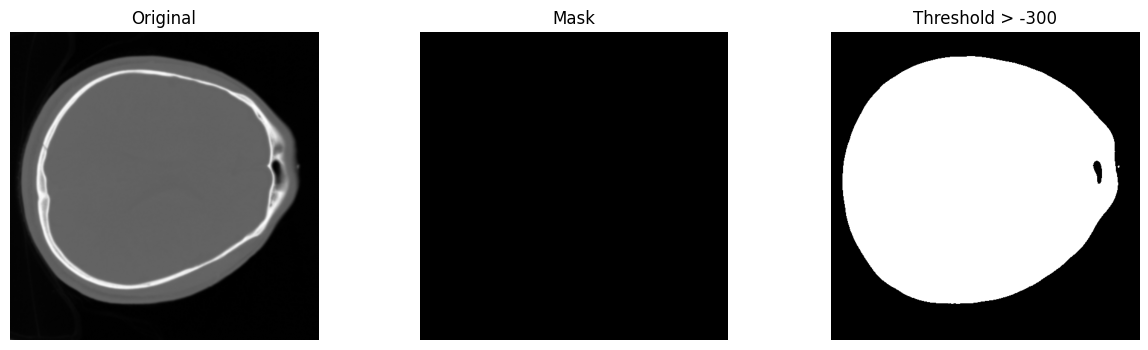

train done.

Processing val


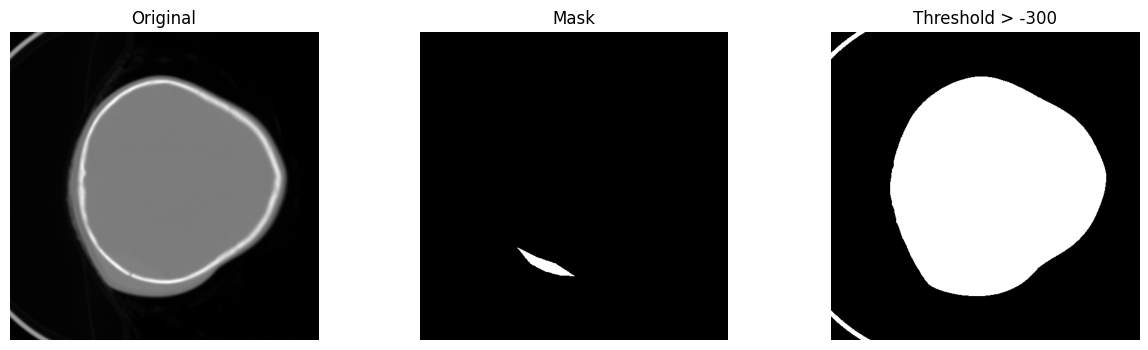

val done.

Processing test


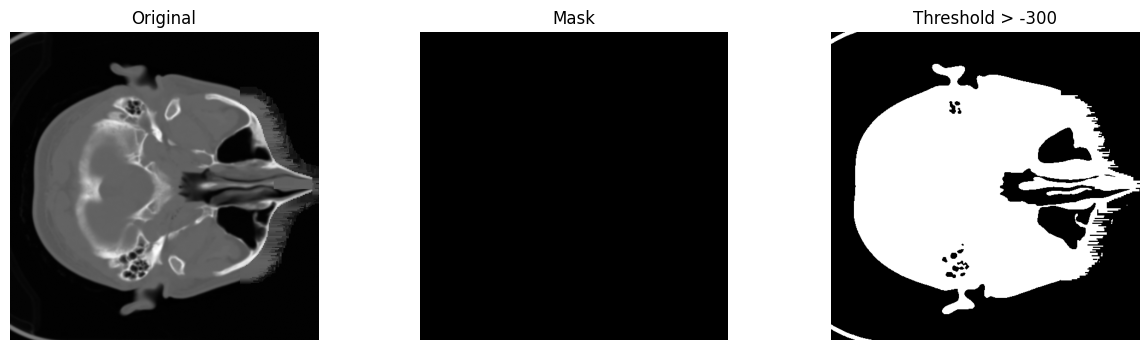

test done.


In [52]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt

splits = ['train', 'val', 'test']

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))  # FIX: consistency

    print(f"\nProcessing {split}")

    sample_file = random.choice(files)

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        if not os.path.exists(mask_path):  # FIX: safety
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        if img.shape != mask.shape:  # FIX: sanity check
            print(f"Shape mismatch in {f}")
            continue

        # --- STEP ---
        brain_mask = img > -300

        # visualize ONE sample
        if f == sample_file:
            plt.figure(figsize=(15,4))

            plt.subplot(1,3,1)
            plt.title("Original")
            plt.imshow(img, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.title("Mask")
            plt.imshow(mask, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.title("Threshold > -300")
            plt.imshow(brain_mask, cmap='gray')
            plt.axis('off')

            plt.show()

    print(f"{split} done.")

#Head isolation


Processing train


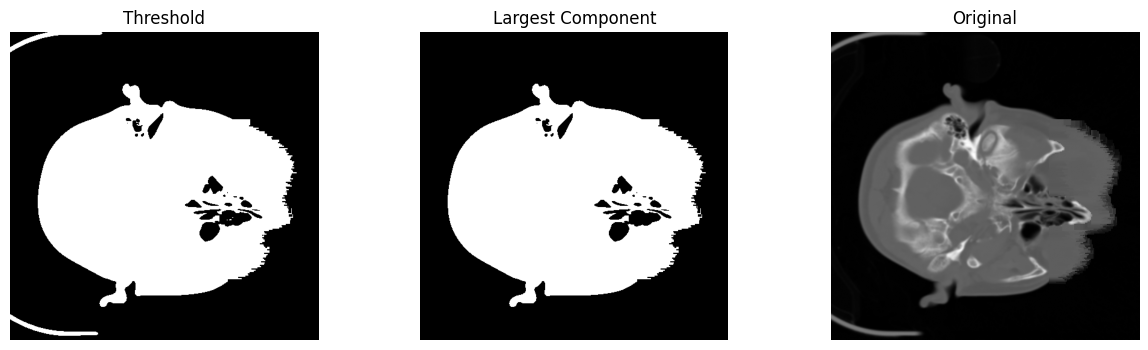

train done.

Processing val


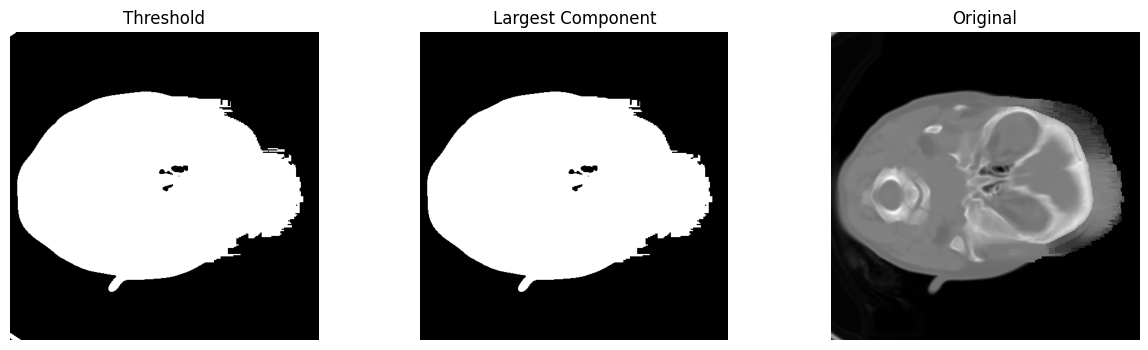

val done.

Processing test


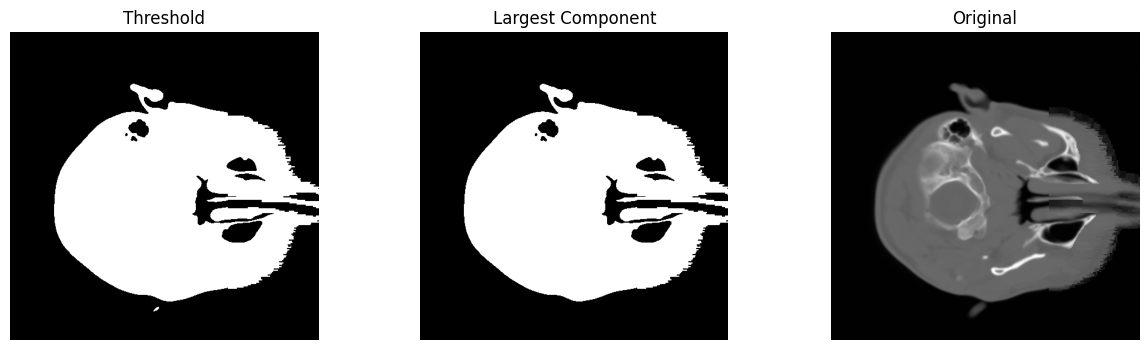

test done.


In [53]:
from scipy.ndimage import label
import os
import numpy as np
import random
import matplotlib.pyplot as plt

splits = ['train', 'val', 'test']

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))  # FIX: consistency

    print(f"\nProcessing {split}")

    sample_file = random.choice(files)

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        if not os.path.exists(mask_path):  # FIX: safety
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        if img.shape != mask.shape:  # FIX: sanity
            print(f"Shape mismatch in {f}")
            continue

        # Step 2 — threshold
        brain_mask = img > -300

        # Step 3 — largest component (robust)
        labeled, num = label(brain_mask)

        if num == 0:
            brain_mask_clean = brain_mask
        else:
            sizes = np.bincount(labeled.ravel())[1:]  # FIX: faster & safer
            largest_label = np.argmax(sizes) + 1
            brain_mask_clean = (labeled == largest_label)

        # visualize ONE sample
        if f == sample_file:
            plt.figure(figsize=(15,4))

            plt.subplot(1,3,1)
            plt.title("Threshold")
            plt.imshow(brain_mask, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.title("Largest Component")
            plt.imshow(brain_mask_clean, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.title("Original")
            plt.imshow(img, cmap='gray')
            plt.axis('off')

            plt.show()

    print(f"{split} done.")

#Bounding Box + Crop


Processing train


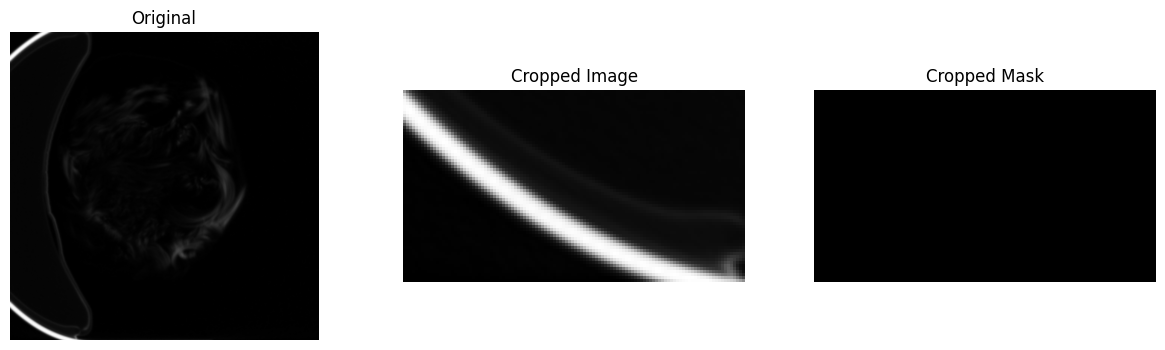

train done.

Processing val


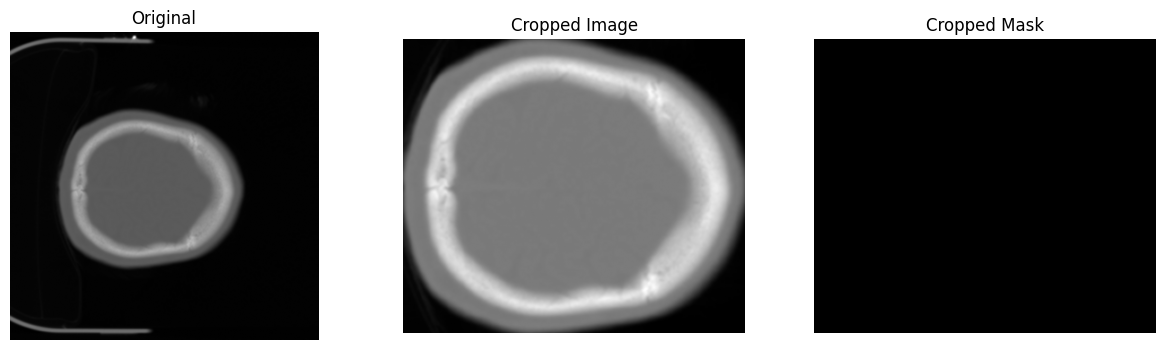

val done.

Processing test


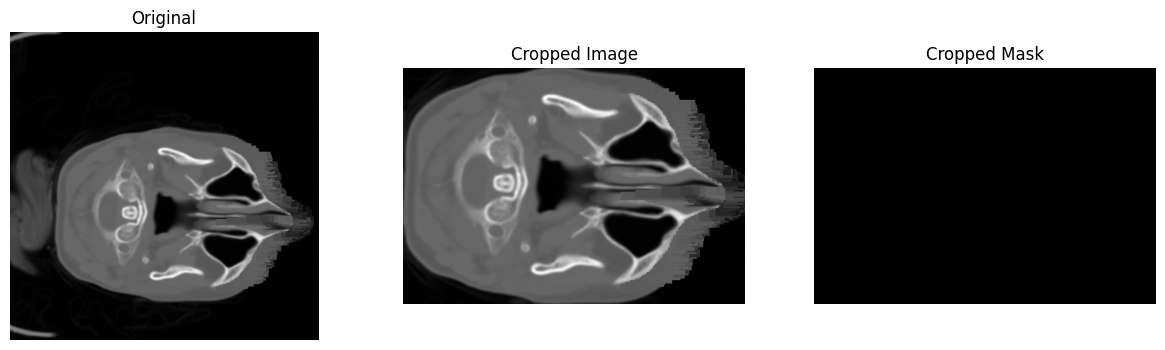

test done.


In [54]:
from scipy.ndimage import label
import os
import numpy as np
import random
import matplotlib.pyplot as plt

splits = ['train', 'val', 'test']

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))  # FIX: reproducibility

    print(f"\nProcessing {split}")

    sample_file = random.choice(files)

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        if not os.path.exists(mask_path):  # FIX: safety
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        if img.shape != mask.shape:  # FIX: sanity
            print(f"Shape mismatch in {f}")
            continue

        # Step 2 — threshold
        brain_mask = img > -300

        # Step 3 — largest component (robust)
        labeled, num = label(brain_mask)

        if num == 0:
            brain_mask_clean = brain_mask
        else:
            sizes = np.bincount(labeled.ravel())[1:]  # FIX: efficient
            largest_label = np.argmax(sizes) + 1
            brain_mask_clean = (labeled == largest_label)

        # Step 4 — bounding box + crop
        coords = np.where(brain_mask_clean)

        if coords[0].size == 0:
            cropped_img = img
            cropped_mask = mask
        else:
            y_min, y_max = coords[0].min(), coords[0].max()
            x_min, x_max = coords[1].min(), coords[1].max()

            # FIX: include last pixel (Python slicing is exclusive)
            cropped_img = img[y_min:y_max+1, x_min:x_max+1]
            cropped_mask = mask[y_min:y_max+1, x_min:x_max+1]

        # visualize ONE sample
        if f == sample_file:
            plt.figure(figsize=(15,4))

            plt.subplot(1,3,1)
            plt.title("Original")
            plt.imshow(img, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.title("Cropped Image")
            plt.imshow(cropped_img, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.title("Cropped Mask")
            plt.imshow(cropped_mask, cmap='gray')
            plt.axis('off')

            plt.show()

    print(f"{split} done.")

#Refined tissue mask


Processing train


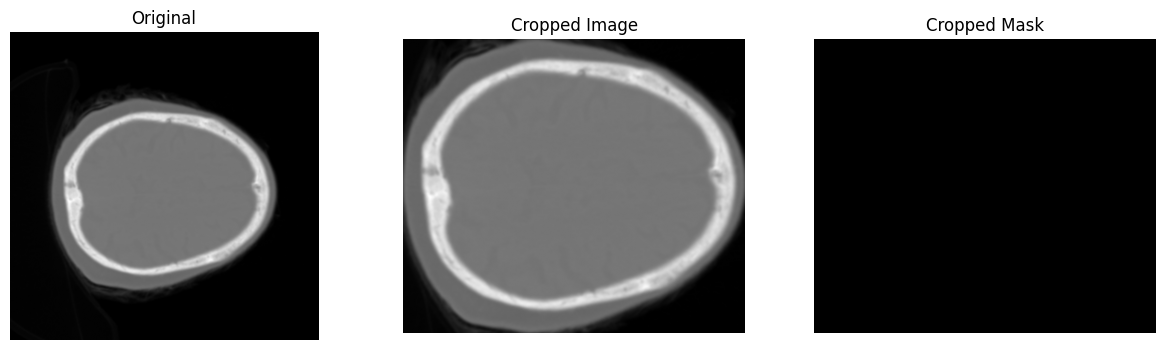

train done.

Processing val


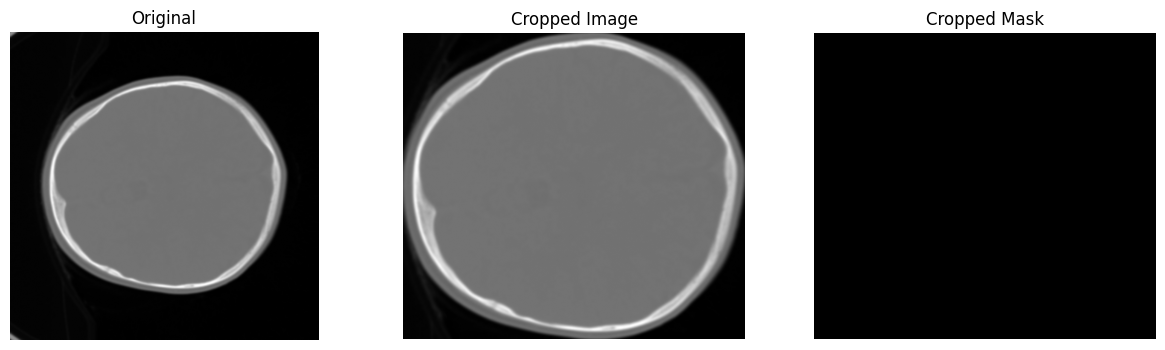

val done.

Processing test


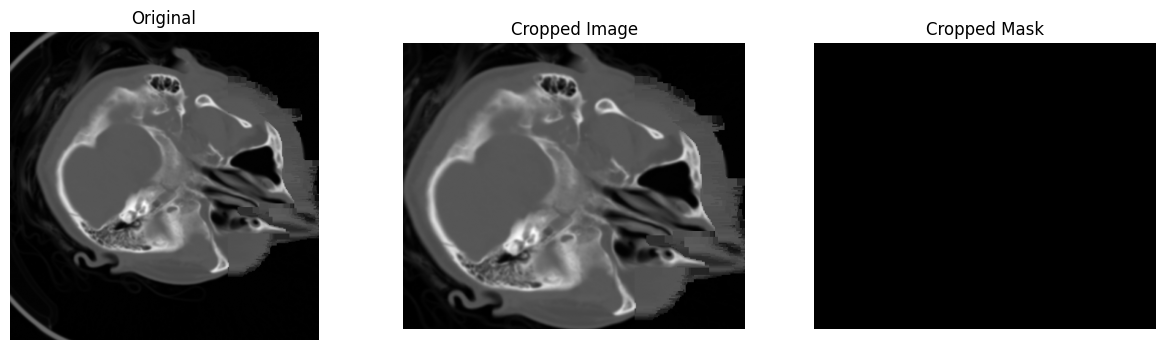

test done.


In [55]:
from scipy.ndimage import label
import os
import numpy as np
import random
import matplotlib.pyplot as plt

splits = ['train', 'val', 'test']

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))  # FIX: consistency

    print(f"\nProcessing {split}")

    sample_file = random.choice(files)

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        if not os.path.exists(mask_path):
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        if img.shape != mask.shape:
            print(f"Shape mismatch in {f}")
            continue

        # Step 2 — threshold
        brain_mask = img > -300

        # Step 3 — largest component
        labeled, num = label(brain_mask)

        if num == 0:
            brain_mask_clean = brain_mask
        else:
            sizes = np.bincount(labeled.ravel())[1:]
            largest_label = np.argmax(sizes) + 1
            brain_mask_clean = (labeled == largest_label)

        # Step 4 — bounding box + crop
        coords = np.where(brain_mask_clean)

        if coords[0].size == 0:
            cropped_img = img
            cropped_mask = mask
        else:
            y_min, y_max = coords[0].min(), coords[0].max()
            x_min, x_max = coords[1].min(), coords[1].max()

            cropped_img = img[y_min:y_max+1, x_min:x_max+1]
            cropped_mask = mask[y_min:y_max+1, x_min:x_max+1]

        # visualize ONE sample
        if f == sample_file:
            plt.figure(figsize=(15,4))

            plt.subplot(1,3,1)
            plt.title("Original")
            plt.imshow(img, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.title("Cropped Image")
            plt.imshow(cropped_img, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.title("Cropped Mask")
            plt.imshow(cropped_mask, cmap='gray')
            plt.axis('off')

            plt.show()

    print(f"{split} done.")

#Resize


Processing train


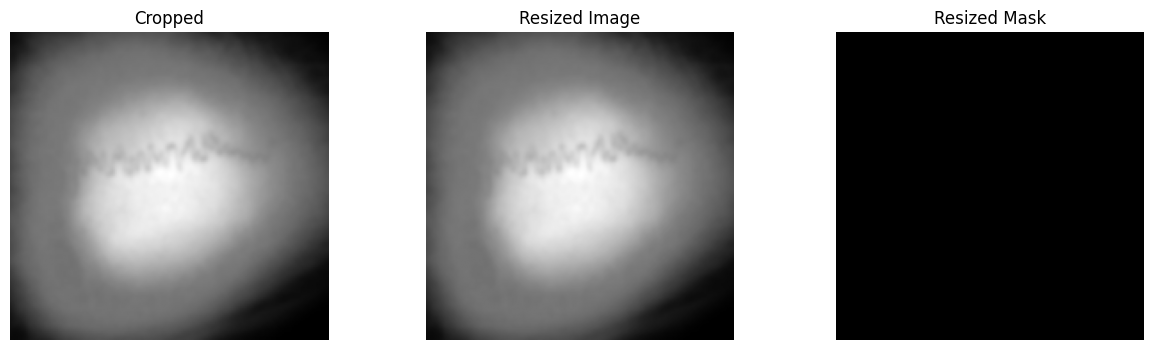

train done.

Processing val


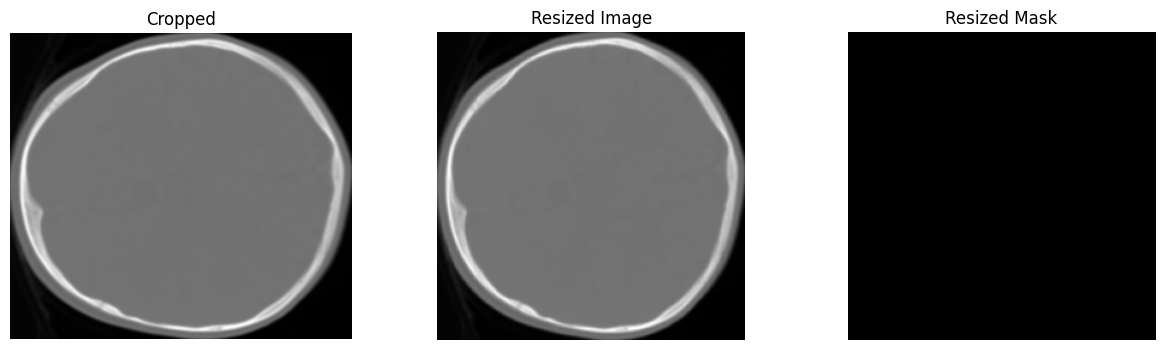

val done.

Processing test


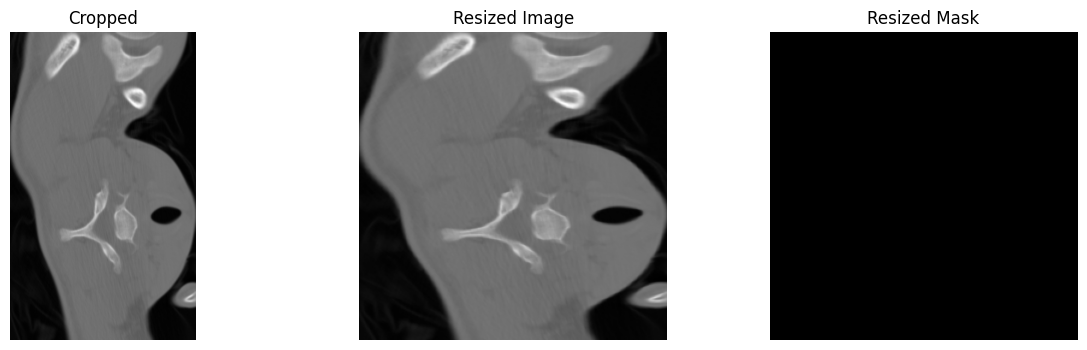

test done.


In [56]:
from scipy.ndimage import label
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2

target_size = (256, 256)

splits = ['train', 'val', 'test']

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))  # FIX: reproducibility

    print(f"\nProcessing {split}")

    sample_file = random.choice(files)

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        if not os.path.exists(mask_path):
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        if img.shape != mask.shape:
            print(f"Shape mismatch in {f}")
            continue

        # Step 2 — threshold
        brain_mask = img > -300

        # Step 3 — largest component
        labeled, num = label(brain_mask)

        if num == 0:
            brain_mask_clean = brain_mask
        else:
            sizes = np.bincount(labeled.ravel())[1:]
            largest_label = np.argmax(sizes) + 1
            brain_mask_clean = (labeled == largest_label)

        # Step 4 — bbox + crop
        coords = np.where(brain_mask_clean)

        if coords[0].size == 0:
            cropped_img = img
            cropped_mask = mask
        else:
            y_min, y_max = coords[0].min(), coords[0].max()
            x_min, x_max = coords[1].min(), coords[1].max()

            cropped_img = img[y_min:y_max+1, x_min:x_max+1]
            cropped_mask = mask[y_min:y_max+1, x_min:x_max+1]

        # Step 5 — resize (FINAL STEP in this notebook)
        img_resized = cv2.resize(cropped_img, target_size, interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(cropped_mask, target_size, interpolation=cv2.INTER_NEAREST)

        # visualize ONE sample
        if f == sample_file:
            plt.figure(figsize=(15,4))

            plt.subplot(1,3,1)
            plt.title("Cropped")
            plt.imshow(cropped_img, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.title("Resized Image")
            plt.imshow(img_resized, cmap='gray')
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.title("Resized Mask")
            plt.imshow(mask_resized, cmap='gray')
            plt.axis('off')

            plt.show()

    print(f"{split} done.")

#Save processed

##Define output directory

In [57]:
save_root = '/content/drive/MyDrive/brain_ct_project/brain_ct_cropped_resized'

splits = ['train', 'val', 'test']

for split in splits:
    os.makedirs(os.path.join(save_root, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(save_root, split, 'masks'), exist_ok=True)

##Full pipeline + save

In [58]:
import os
import numpy as np
import cv2
from scipy.ndimage import label

target_size = (256, 256)

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))  # FIX: reproducibility

    print(f"\nProcessing {split}")

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        if not os.path.exists(mask_path):
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        if img.shape != mask.shape:
            print(f"Shape mismatch in {f}")
            continue

        # Step 2 — threshold
        brain_mask = img > -300

        # Step 3 — largest component
        labeled, num = label(brain_mask)

        if num == 0:
            brain_mask_clean = brain_mask
        else:
            sizes = np.bincount(labeled.ravel())[1:]
            largest_label = np.argmax(sizes) + 1
            brain_mask_clean = (labeled == largest_label)

        # Step 4 — bbox + crop
        coords = np.where(brain_mask_clean)

        if coords[0].size == 0:
            cropped_img = img
            cropped_mask = mask
        else:
            y_min, y_max = coords[0].min(), coords[0].max()
            x_min, x_max = coords[1].min(), coords[1].max()

            cropped_img = img[y_min:y_max+1, x_min:x_max+1]
            cropped_mask = mask[y_min:y_max+1, x_min:x_max+1]

        # Step 5 — resize (final step here)
        img_resized = cv2.resize(cropped_img, target_size, interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(cropped_mask, target_size, interpolation=cv2.INTER_NEAREST)

        # --- SAVE (RAW, no normalization, no channel) ---
        save_img_path = os.path.join(save_root, split, 'images', f)
        save_mask_path = os.path.join(save_root, split, 'masks', f)

        np.save(save_img_path, img_resized)
        np.save(save_mask_path, mask_resized)

    print(f"{split} saved.")


Processing train
train saved.

Processing val
val saved.

Processing test
test saved.


##proper validation

In [59]:
import random
import os
import numpy as np

split = 'train'

img_dir = os.path.join(save_root, split, 'images')

files = os.listdir(img_dir)
f = random.choice(files)

sample = np.load(os.path.join(img_dir, f))

print("File:", f)
print("Shape:", sample.shape)
print("Min/Max:", sample.min(), sample.max())

File: slice_00361.npy
Shape: (256, 256)
Min/Max: -1006.49817 1693.2068


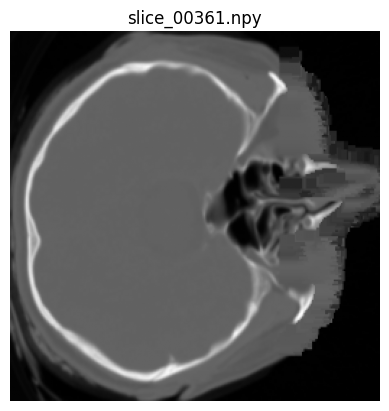

In [60]:
import matplotlib.pyplot as plt

plt.imshow(sample, cmap='gray')
plt.title(f)
plt.axis('off')
plt.show()